# Hedge funds' "free carry" — is the Treasury Basis Trade really riskless? 🏦
### The most-levered trade in the bond market, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_carry%3F: Busted](https://img.shields.io/badge/Free_carry%3F-Busted-8b949e?style=flat-square)

There's a trade that fixed-income hedge funds love: buy a cheap government bond, sell the slightly-pricier bond *future* against it, and pocket the tiny gap as it closes — the **carry**. The position is hedged, the gap is steady, and it prints money almost every single day. Lever it **50 to 100 times** with borrowed money and a 1.5%-a-year trickle becomes **70%+ a year**. It looks like *free carry*.

But "steady and hedged" hides a second story. The same trade, at the leverage it actually runs, is one **funding shock** away from a margin call that wipes you out — which is exactly what nearly happened in **March 2020**, when the Fed had to step in. This notebook pulls the two stories apart: the carry is *real*, and the "free" part is a *leverage illusion*.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo test and the tail math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Clean cash-vs-futures bond prices and repo rates aren't free, so we **build a transparent carry model**: the 10-year yield minus a short funding rate (a repo proxy). It's a *model* — we say so throughout — but it captures the two things that matter: a smooth positive carry and a rare, violent tail. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_basis_trade import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real basis-model cache present:", HAVE_REAL,
      "| model days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-31', 'end': '2026-06-18', 'days': 6004, 'years': 23.8, 'mean_yield': 3.11, 'mean_funding': 1.68, 'mean_carry': 1.42, 'frac_pos': 86.5, 'ann_unlev': 1.47, 'hac_t': 11.71, 'sharpe': 2.86, 'sharpe_t': 13.9, 'placebo_p': 0.0, 'lev': [(1, 1.5, 2.86, -2.6, -0.4, -0.1), (50, 73.4, 2.86, -75.1, -18.5, -5.8), (100, 146.9, 2.86, -94.6, -36.9, -11.7)], 'skew': -0.27, 'exkurt': 9.8, 'worst_day': -0.369, 'worst_5day': -0.706, 'mar2020': (-0.31, -15.8, -31.2), 'costs': (73.4, 71.4, 2.0), 'syn': [(0.0, 0.0, 0.0, -4, -95), (2.5, 2.5, 12.8, -1, -58)]}


real basis-model cache present: True | model days: 6004


## The answer first

| Question | Answer |
|---|---|
| Is the carry actually there? | **Yes — really there.** The bond out-yields the funding cost on **86%** of days; the carry is rock-solid statistically (it'd happen by chance essentially **never**). |
| So is it free money? | **No.** That's a *risk premium* — you're paid for bearing risk, not given a free lunch. Unlevered it earns about **1.5% a year**. |
| Where does "70% a year" come from? | **Leverage.** Multiply 1.5% by 50× and you get **73%** — but you've multiplied the *risk* by 50× too. The risk-adjusted reward (the Sharpe ratio) doesn't budge. |
| What's the catch? | **The tail.** At 50× a single bad day is **-18%**, the worst drawdown is **-75%**, and a March-2020-style funding shock takes **−16%** in two weeks — while a margin call forces you to sell at the worst moment. |

> The carry is real. "Free" is the lie. It's a smooth income stream sitting on top of a rare, ruinous crash — picking up pennies in front of a steamroller.

## 1 · The claim

> *"The cash Treasury yields a hair more than it costs to finance it in repo, and the future trades a hair rich to the cash. Buy the cash, short the future, hedge out the interest-rate risk, and you harvest the gap as it converges to zero at delivery — a near-riskless **carry**. It's tiny, so lever it 50–100× and it's a double-digit return on equity, almost every day."*

This is a flagship **relative-value** trade for bond hedge funds, and the mechanics are textbook (the *implied repo rate*, the *net basis*). The seduction is the *smoothness*: day after day of quiet positive accrual. We'll rebuild that carry and ask the two questions the pitch fuses: is the carry real, and is "free" true?

## 2 · So what?

Two things hide inside "free carry," and only one is benign. (1) *Is there a real carry?* Sure — bonds out-yield short funding most of the time; that's a genuine premium. But (2) *is it free?* A premium is a payment **for bearing risk**. The smoothness tempts you to lever it to the moon — and that's where the danger lives, because leverage doesn't improve the *quality* of the return (the risk-adjusted reward stays fixed), it only scales the swings. A trade that's calm 99% of the time and catastrophic 1% of the time **looks** free right up until the 1%.

## 3 · How would we even know?

We rebuild the carry on a **transparent model**: the 10-year Treasury yield minus a short funding rate (a repo proxy). That daily net carry, earned with a one-day lag, is the unlevered basis return over **24 years** (2002-07-31 → 2026-06-18).

1. **Is the carry real?** Test the unlevered return for a genuine positive edge — the honest, *leverage-proof* question.
2. **Apply real leverage.** Multiply the exact same return by 50× and 100× — what the trade actually runs — and watch the drawdown.
3. **Stress the tail.** Replay **March 2020**, when repo seized and the basis blew up, and see what a forced unwind costs at 50×.

## 4 · The teardown — let's actually look

**First, the carry itself.** Here's the net carry — the 10-year yield minus the short funding rate — over two decades. It's positive almost the whole time: that's the steady trickle the trade harvests.

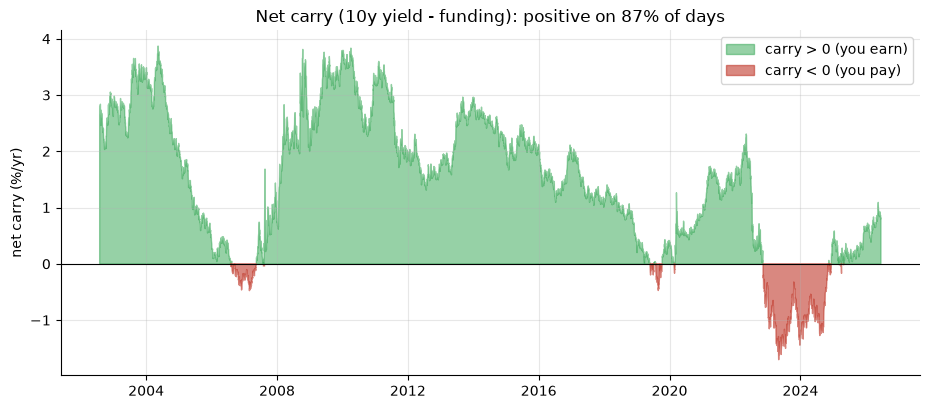

mean net carry %/yr: 1.42  | positive on 87% of days


In [2]:
if HAVE_REAL:
    nc = F['net_carry']
    fig, ax = plt.subplots(figsize=(9.4, 4.2))
    ax.fill_between(nc.index, 0, nc.values, where=(nc.values>=0), color=GREEN, alpha=.5, label='carry > 0 (you earn)')
    ax.fill_between(nc.index, 0, nc.values, where=(nc.values<0), color=RED, alpha=.6, label='carry < 0 (you pay)')
    ax.axhline(0, c='k', lw=.8)
    ax.set_title(f'Net carry (10y yield - funding): positive on {(nc>0).mean()*100:.0f}% of days')
    ax.set_ylabel('net carry (%/yr)'); ax.legend()
    plt.tight_layout(); plt.show()
    print('mean net carry %/yr:', round(nc.mean(),2), ' | positive on', f'{(nc>0).mean()*100:.0f}% of days')
else:
    print(f"no cache - frozen: carry ~{R['mean_carry']}%/yr, positive on {R['frac_pos']:.0f}% of days")

Positive on **86%** of days, averaging **1.4%/yr** — a real, persistent premium. Unlevered, the basis return is silky: a thin, steady climb. Which is exactly what makes the next step so tempting.

**Now lever it.** Sharpe — the risk-adjusted reward — is the *same* at every leverage (it has to be: leverage multiplies the gain and the swings together). But the **drawdown** is not. Here's the identical return at 1×, 50×, 100×.

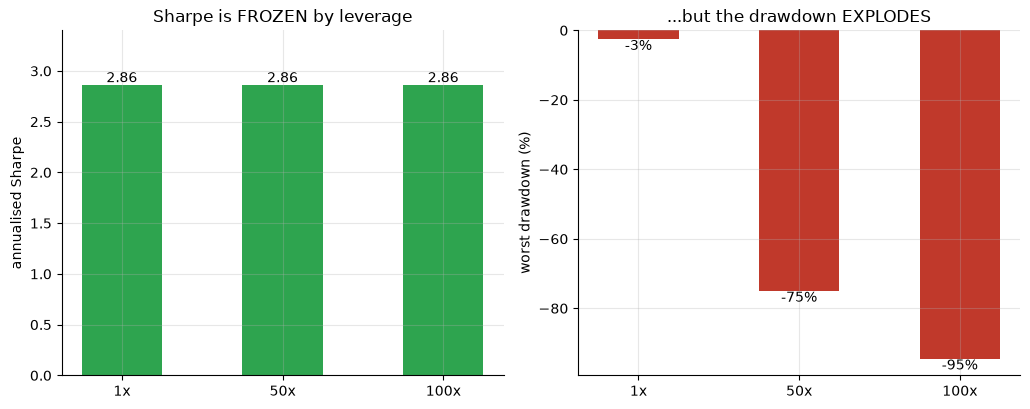

Sharpe at 1x/50x/100x: [2.86, 2.86, 2.86]   drawdown: [-3.0, -75.0, -95.0]


In [3]:
levs = [1, 50, 100]
if HAVE_REAL:
    rows = st.leverage_table(F, leverages=tuple(levs))
    sh = [r['sharpe'] for r in rows]; dd = [r['max_dd']*100 for r in rows]; ann=[r['ann_return']*100 for r in rows]
else:
    sh = [r[2] for r in R['lev']]; dd = [r[3] for r in R['lev']]; ann=[r[1] for r in R['lev']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
x = np.arange(len(levs))
a1.bar(x, sh, color=GREEN, width=.5)
for i,s in enumerate(sh): a1.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom')
a1.set_xticks(x); a1.set_xticklabels([f'{L}x' for L in levs]); a1.set_ylim(0,3.4)
a1.set_title('Sharpe is FROZEN by leverage'); a1.set_ylabel('annualised Sharpe')
a2.bar(x, dd, color=RED, width=.5)
for i,d in enumerate(dd): a2.annotate(f'{d:.0f}%',(i,d),ha='center',va='top')
a2.set_xticks(x); a2.set_xticklabels([f'{L}x' for L in levs])
a2.set_title('...but the drawdown EXPLODES'); a2.set_ylabel('worst drawdown (%)')
plt.tight_layout(); plt.show()
print('Sharpe at 1x/50x/100x:', [round(s,2) for s in sh], '  drawdown:', [round(d,0) for d in dd])

There's the trick in one picture. The Sharpe is **2.86** at *every* leverage — leverage adds **no** risk-adjusted reward. But the drawdown goes from a harmless **-3%** at 1× to **-75%** at 50× to a near-total **-95%** at 100×. The "70% a year" is real — and so is the −75% that comes with it.

**The tail — what a funding shock does.** March 2020: repo froze, the basis dislocated, levered funds got margin-called and force-sold into the move. Here's what those two weeks cost the *same* trade at each leverage.

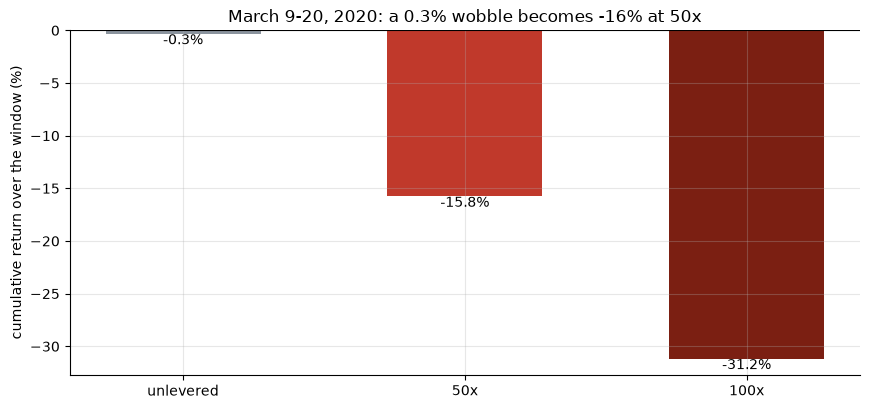

Mar 2020 (10 trading days): unlev -0.3% | 50x -15.8% | 100x -31.2%


In [4]:
if HAVE_REAL:
    fs = st.funding_shock(F, '2020-03-09', '2020-03-20', leverages=(1,50,100))
    vals = [fs['unlev']*100, fs['L50']*100, fs['L100']*100]
else:
    vals = list(R['mar2020'])
labels = ['unlevered', '50x', '100x']
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(labels, vals, color=[GREY, RED, '#7b1f12'], width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_title('March 9-20, 2020: a 0.3% wobble becomes -16% at 50x')
ax.set_ylabel('cumulative return over the window (%)')
plt.tight_layout(); plt.show()
print('Mar 2020 (10 trading days): unlev', f'{vals[0]:.1f}%', '| 50x', f'{vals[1]:.1f}%', '| 100x', f'{vals[2]:.1f}%')

A **-0.3%** wobble in the unlevered basis — nothing — becomes a **-16%** hit at 50× in ten trading days. And that's *before* the margin calls that force you to sell into the dislocation, deepening it. This is the "hidden leverage risk" the *free-carry* story leaves out.

## 5 · The verdict

- **Signal — Real.** The carry genuinely exists (positive on 86% of days, statistically overwhelming). But it's a **risk premium** — beta you're paid for — not free alpha.
- **Tradability — Mirage.** The big return is the small premium **× leverage**; the Sharpe never improves, the drawdown hits **-75%** at 50×, and a funding shock force-unwinds you. Not a survivable strategy.
- **"Free carry"? — Busted.** Smooth income on top of a rare, ruinous tail. Picking up pennies in front of a steamroller — the [FX carry trade](../364-fx-carry-trade/) wearing a Treasury costume.

## 6 · Could you actually trade it? — count the cost vs the tail

People assume a trade like this dies on transaction costs. It doesn't — the turnover is tiny (a futures roll a few times a year). Here's gross vs net at 50×: costs barely register. The trade doesn't die on the spread. It dies on the **tail**.

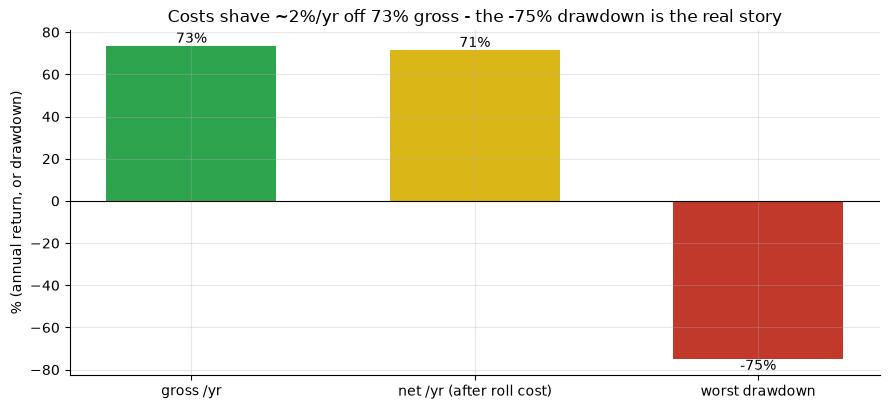

50x: gross 73%/yr  net 71%/yr  (cost 2%/yr)  |  worst drawdown -75%


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(F, leverage=50.0)
    gross, net, cost = c['gross_ann']*100, c['net_ann']*100, c['cost_ann']*100
    dd50 = st.leverage_table(F, leverages=(50,))[0]['max_dd']*100
else:
    gross, net, cost = R['costs']; dd50 = R['lev'][1][3]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(['gross /yr','net /yr (after roll cost)','worst drawdown'], [gross, net, dd50],
       color=[GREEN, AMBER, RED], width=.6)
for i,v in enumerate([gross,net,dd50]):
    ax.annotate(f'{v:.0f}%',(i,v),ha='center',va=('bottom' if v>=0 else 'top'))
ax.axhline(0, c='k', lw=.8)
ax.set_title('Costs shave ~2%/yr off 73% gross - the -75% drawdown is the real story')
ax.set_ylabel('% (annual return, or drawdown)')
plt.tight_layout(); plt.show()
print(f'50x: gross {gross:.0f}%/yr  net {net:.0f}%/yr  (cost {cost:.0f}%/yr)  |  worst drawdown {dd50:.0f}%')

Net of a quarterly roll the return is still ~**71%/yr**. You *cannot* cost your way out of this trade — but you can be wiped out by it. The honest version isn't "collect free carry forever"; it's "collect a small premium until a funding shock takes the whole stack." That's not a strategy you can size; it's a short option on financial calm.

## 7 · Going further 🚪

- **The currency cousin.** [Study 364 — FX-Carry-Trade](../364-fx-carry-trade/) is the same "earn the rate differential" carry with the same crash tail — proof that carry's free-lunch reputation is one illusion across asset classes.
- **The raw material.** [Study 132 — Yield-Curve-Steepener](../132-yield-curve-steepener/) trades the very term-structure spread the basis carry comes from.
- **Tighten the model.** Swap our 10y−bill proxy for a real cheapest-to-deliver basis and GC repo, and the carry shrinks but the *tail gets worse* — repo spikes above bills exactly in a crisis, so our funding shock is, if anything, understated.

*Think the basis is free carry? Lever it 50×, replay March 2020, and show the book surviving the margin call — then we'll talk.*